In [2]:
import numpy as np
import pandas as pd

In [3]:
match=pd.read_csv('matches.csv')
delivery=pd.read_csv('deliveries.csv')

In [4]:
#according to every match we calculated its each inning score soo that we can find out win probabilities
total_score_df=delivery.groupby(['match_id','inning']).sum()['total_runs'].reset_index()

In [5]:
#we have taken data of only first innings
total_score_df=total_score_df[total_score_df['inning']==1]

In [6]:
total_score_df

,match_id,inning,total_runs
0,1,1,207
2,2,1,184
4,3,1,183
6,4,1,163
8,5,1,157
...,...,...,...
1518,11347,1,143
1520,11412,1,136
1522,11413,1,171
1524,11414,1,155


In [7]:
#we have merged match and delivery_df on the basis of match_id and id
match_df=match.merge(total_score_df[['match_id','total_runs']],left_on='id',right_on='match_id')

In [8]:
match_df

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,1,207
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,2,184
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,3,183
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,4,163
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,11347,143
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,11412,136
753,11413,IPL-2019,Visakhapatnam,08-05-2019,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals,field,normal,0,Delhi Capitals,0,2,RR Pant,ACA-VDCA Stadium,NaN,NaN,NaN,11413,171
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,11414,155


In [9]:
teams=[
    'Sunrises Hyderabad',
    'Mumbai Indians',
    'Royal Challengers Bangalore',
    'Kolkata Knight Riders',
    'Kings XI Punjab',
    'Chennai Super Kings',
    'Rajasthan Royals',
    'Delhi Capitals'
]

In [10]:
match_df['team1']=match_df['team1'].str.replace('Delhi Daredevils','Delhi Capitals')
match_df['team2']=match_df['team2'].str.replace('Delhi Daredevils','Delhi Capitals')

match_df['team1']=match_df['team1'].str.replace('Deccan Chargers','Sunrises Hyderabad')
match_df['team2']=match_df['team2'].str.replace('Deccan Chargers','Sunrises Hyderabad')

In [11]:
match_df=match_df[match_df['team1'].isin(teams)]
match_df=match_df[match_df['team2'].isin(teams)]

In [12]:
match_df.shape

(544, 20)

In [13]:
match_df

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157
6,7,IPL-2017,Mumbai,09-04-2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,7,178
7,8,IPL-2017,Indore,10-04-2017,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,8,148
10,11,IPL-2017,Kolkata,13-04-2017,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,8,SP Narine,Eden Gardens,A Deshmukh,NJ Llong,NaN,11,170
11,12,IPL-2017,Bangalore,14-04-2017,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,KA Pollard,M Chinnaswamy Stadium,KN Ananthapadmanabhan,AK Chaudhary,NaN,12,142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,11346,IPL-2019,Mohali,05-05-2019,Chennai Super Kings,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,KL Rahul,IS Bindra Stadium,KN Ananthapadmanabhan,C Shamshuddin,Bruce Oxenford,11346,172
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,11347,143
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,11412,136
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,11414,155


In [14]:
match_df=match_df[match_df['dl_applied']==0]

In [15]:
match_df

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,match_id,total_runs
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Capitals,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,5,157
6,7,IPL-2017,Mumbai,09-04-2017,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,N Rana,Wankhede Stadium,Nitin Menon,CK Nandan,NaN,7,178
7,8,IPL-2017,Indore,10-04-2017,Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,bat,normal,0,Kings XI Punjab,0,8,AR Patel,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,8,148
10,11,IPL-2017,Kolkata,13-04-2017,Kings XI Punjab,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,8,SP Narine,Eden Gardens,A Deshmukh,NJ Llong,NaN,11,170
11,12,IPL-2017,Bangalore,14-04-2017,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,4,KA Pollard,M Chinnaswamy Stadium,KN Ananthapadmanabhan,AK Chaudhary,NaN,12,142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,11346,IPL-2019,Mohali,05-05-2019,Chennai Super Kings,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,KL Rahul,IS Bindra Stadium,KN Ananthapadmanabhan,C Shamshuddin,Bruce Oxenford,11346,172
751,11347,IPL-2019,Mumbai,05-05-2019,Kolkata Knight Riders,Mumbai Indians,Mumbai Indians,field,normal,0,Mumbai Indians,0,9,HH Pandya,Wankhede Stadium,Nanda Kishore,O Nandan,S Ravi,11347,143
752,11412,IPL-2019,Chennai,07-05-2019,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,bat,normal,0,Mumbai Indians,0,6,AS Yadav,M. A. Chidambaram Stadium,Nigel Llong,Nitin Menon,Ian Gould,11412,136
754,11414,IPL-2019,Visakhapatnam,10-05-2019,Delhi Capitals,Chennai Super Kings,Chennai Super Kings,field,normal,0,Chennai Super Kings,0,6,F du Plessis,ACA-VDCA Stadium,Sundaram Ravi,Bruce Oxenford,Chettithody Shamshuddin,11414,155


In [16]:
match_df=match_df[['match_id','city','winner','total_runs']]

In [17]:
delivery_df=match_df.merge(delivery,on='match_id')

In [18]:
delivery_df=delivery_df[delivery_df['inning']==2]

In [19]:
delivery_df.shape

(61444, 24)

In [20]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder
124,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,1,AP Tare,...,0,0,0,0,0,0,0,NaN,NaN,NaN
125,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,2,AP Tare,...,0,0,0,0,0,1,1,NaN,NaN,NaN
126,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,3,AP Tare,...,0,0,0,0,0,0,0,NaN,NaN,NaN
127,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,4,AP Tare,...,0,0,0,0,1,0,1,NaN,NaN,NaN
128,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,5,SW Billings,...,0,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127048,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,0,0,0,0,1,0,1,NaN,NaN,NaN
127049,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,0,0,0,0,2,0,2,NaN,NaN,NaN
127050,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
127051,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,0,0,0,0,2,0,2,NaN,NaN,NaN


In [21]:
delivery_df['current_score']=delivery_df.groupby('match_id')['total_runs_y'].cumsum()

In [22]:
#i am being able to find runs left after every ball
delivery_df['runs_left']=(delivery_df['total_runs_x']+1)-delivery_df['current_score']

In [23]:
#balls left after each ball
delivery_df['balls_left']=126-(delivery_df['over']*6+delivery_df['ball'])

In [24]:
delivery_df['player_dismissed'].head(20)

124    NaN
125    NaN
126    NaN
127    NaN
128    NaN
129    NaN
130    NaN
131    NaN
132    NaN
133    NaN
134    NaN
135    NaN
136    NaN
137    NaN
138    NaN
139    NaN
140    NaN
141    NaN
142    NaN
143    NaN
Name: player_dismissed, dtype: str

In [25]:
delivery_df['player_dismissed'] = (
    delivery_df['player_dismissed']
    .notnull()
    .astype(int)
)

delivery_df['player_dismissed'].value_counts(dropna=False)

player_dismissed
0    58419
1     3025
Name: count, dtype: int64

In [26]:
wickets = delivery_df.groupby('match_id')['player_dismissed'].cumsum()

delivery_df['wickets'] = 10 - wickets

delivery_df[['player_dismissed','wickets']].head(20)

,player_dismissed,wickets
124,0,10
125,0,10
126,0,10
127,0,10
128,0,10
129,0,10
130,0,10
131,0,10
132,0,10
133,0,10


In [27]:
delivery_df

,match_id,city,winner,total_runs_x,inning,batting_team,bowling_team,over,ball,batsman,...,batsman_runs,extra_runs,total_runs_y,player_dismissed,dismissal_kind,fielder,current_score,runs_left,balls_left,wickets
124,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,1,AP Tare,...,0,0,0,0,NaN,NaN,0,158,119,10
125,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,2,AP Tare,...,0,1,1,0,NaN,NaN,1,157,118,10
126,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,3,AP Tare,...,0,0,0,0,NaN,NaN,1,157,117,10
127,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,4,AP Tare,...,1,0,1,0,NaN,NaN,2,156,116,10
128,5,Bangalore,Royal Challengers Bangalore,157,2,Delhi Daredevils,Royal Challengers Bangalore,1,5,SW Billings,...,0,0,0,0,NaN,NaN,2,156,115,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127048,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,...,1,0,1,0,NaN,NaN,152,1,4,5
127049,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,...,2,0,2,0,NaN,NaN,154,-1,3,5
127050,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,...,1,0,1,1,run out,KH Pandya,155,-2,2,4
127051,11415,Hyderabad,Mumbai Indians,152,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,...,2,0,2,0,NaN,NaN,157,-4,1,4


In [28]:
#current run rate
delivery_df['crr']=(delivery_df['current_score']*6)/(120-delivery_df['balls_left'])

In [29]:
#required run rate
delivery_df['rrr']=(delivery_df['runs_left']*6)/delivery_df['balls_left']

In [30]:
def result(row):
    return 1 if row['batting_team']==row['winner'] else 0

In [31]:
delivery_df['result']=delivery_df.apply(result,axis=1)

In [32]:
final_df=delivery_df[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr','result']]

In [33]:
final_df

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
124,Delhi Daredevils,Royal Challengers Bangalore,Bangalore,158,119,10,157,0.000000,7.966387,0
125,Delhi Daredevils,Royal Challengers Bangalore,Bangalore,157,118,10,157,3.000000,7.983051,0
126,Delhi Daredevils,Royal Challengers Bangalore,Bangalore,157,117,10,157,2.000000,8.051282,0
127,Delhi Daredevils,Royal Challengers Bangalore,Bangalore,156,116,10,157,3.000000,8.068966,0
128,Delhi Daredevils,Royal Challengers Bangalore,Bangalore,156,115,10,157,2.400000,8.139130,0
...,...,...,...,...,...,...,...,...,...,...
127048,Chennai Super Kings,Mumbai Indians,Hyderabad,1,4,5,152,7.862069,1.500000,0
127049,Chennai Super Kings,Mumbai Indians,Hyderabad,-1,3,5,152,7.897436,-2.000000,0
127050,Chennai Super Kings,Mumbai Indians,Hyderabad,-2,2,4,152,7.881356,-6.000000,0
127051,Chennai Super Kings,Mumbai Indians,Hyderabad,-4,1,4,152,7.915966,-24.000000,0


In [34]:
final_df=final_df.sample(final_df.shape[0])

In [35]:
final_df.sample()

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
32584,Delhi Daredevils,Rajasthan Royals,Ahmedabad,24,39,6,141,8.740741,3.692308,1


In [36]:
final_df = final_df[final_df['runs_left'] >= 0]

final_df = final_df[final_df['balls_left'] > 0]

final_df = final_df.replace([float('inf'), float('-inf')], np.nan)

final_df = final_df.dropna()

In [37]:
final_df.isnull().sum()

batting_team    0
bowling_team    0
city            0
runs_left       0
balls_left      0
wickets         0
total_runs_x    0
crr             0
rrr             0
result          0
dtype: int64

In [38]:
final_df.describe()

,runs_left,balls_left,wickets,total_runs_x,crr,rrr,result
count,60386.000000,60386.000000,60386.000000,60386.000000,60386.000000,60386.000000,60386.00000
mean,94.092588,63.279966,7.541483,165.543354,7.434319,10.679646,0.52176
std,49.676697,33.083109,2.121188,29.355533,2.293980,12.650403,0.49953
min,0.000000,1.000000,0.000000,65.000000,0.000000,0.000000,0.00000
25%,55.000000,35.000000,6.000000,147.000000,6.260870,7.280899,0.00000
50%,93.000000,64.000000,8.000000,165.000000,7.473684,9.012605,1.00000
75%,131.000000,92.000000,9.000000,185.000000,8.680851,11.057143,1.00000
max,250.000000,119.000000,10.000000,250.000000,42.000000,588.000000,1.00000


In [39]:
final_df.shape

(60386, 10)

In [40]:
x=final_df.iloc[:,:-1]
y=final_df.iloc[:,-1]
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [41]:
x_train

,batting_team,bowling_team,city,runs_left,balls_left,wickets,total_runs_x,crr,rrr
43176,Delhi Daredevils,Chennai Super Kings,Chennai,62,65,6,112,5.563636,5.723077
5917,Kolkata Knight Riders,Deccan Chargers,Kolkata,93,101,8,110,5.684211,5.524752
97152,Kolkata Knight Riders,Chennai Super Kings,Chennai,70,68,7,134,7.500000,6.176471
65863,Chennai Super Kings,Rajasthan Royals,Jaipur,117,108,9,126,5.000000,6.500000
8011,Kings XI Punjab,Delhi Daredevils,Chandigarh,158,117,10,158,2.000000,8.102564
...,...,...,...,...,...,...,...,...,...
35899,Mumbai Indians,Chennai Super Kings,Mumbai,131,88,10,180,9.375000,8.931818
99685,Mumbai Indians,Royal Challengers Bangalore,Mumbai,157,61,8,235,8.033898,15.442623
107423,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata,3,12,4,182,10.000000,1.500000
63751,Delhi Daredevils,Rajasthan Royals,Jaipur,38,52,8,141,9.176471,4.384615


In [42]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

trf = ColumnTransformer([
    ('trf', OneHotEncoder(sparse_output=False, drop='first'),
     ['batting_team', 'bowling_team', 'city'])
], remainder='passthrough')

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [44]:
pipe=Pipeline(steps=[
    ('step1',trf),
    ('step2',LogisticRegression(solver='liblinear'))
])

In [45]:
pipe.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('step1', ...), ('step2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['batting_team','bowling_team','city',...,'total_runs_x','crr','rrr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('trf', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwer

In [46]:
y_pred=pipe.predict(x_test)

In [47]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8067560854446101

In [48]:
pipe.predict_proba(x_test)[3]

array([0.83348392, 0.16651608])

In [49]:
#code yo check for particular match
def match_progression(x_df,match_id,pipe):
    match = x_df[x_df['match_id'] == match_id]
    match = match[(match['ball'] == 6)]
    temp_df = match[['batting_team','bowling_team','city','runs_left','balls_left','wickets','total_runs_x','crr','rrr']].dropna()
    temp_df = temp_df[temp_df['balls_left'] != 0]
    result = pipe.predict_proba(temp_df)
    temp_df['lose'] = np.round(result.T[0]*100,1)
    temp_df['win'] = np.round(result.T[1]*100,1)
    temp_df['end_of_over'] = range(1,temp_df.shape[0]+1)
    
    target = temp_df['total_runs_x'].values[0]
    runs = list(temp_df['runs_left'].values)
    new_runs = runs[:]
    runs.insert(0,target)
    temp_df['runs_after_over'] = np.array(runs)[:-1] - np.array(new_runs)
    wickets = list(temp_df['wickets'].values)
    new_wickets = wickets[:]
    new_wickets.insert(0,10)
    wickets.append(0)
    w = np.array(wickets)
    nw = np.array(new_wickets)
    temp_df['wickets_in_over'] = (nw - w)[0:temp_df.shape[0]]
    
    print("Target-",target)
    temp_df = temp_df[['end_of_over','runs_after_over','wickets_in_over','lose','win']]
    return temp_df,target

In [50]:
temp_df,target = match_progression(delivery_df,74,pipe)
temp_df

Target- 178


,end_of_over,runs_after_over,wickets_in_over,lose,win
8260,1,3,0,58.2,41.8
8268,2,8,0,53.6,46.4
8274,3,1,0,59.0,41.0
8280,4,7,1,69.1,30.9
8286,5,12,0,59.7,40.3
8292,6,13,0,48.0,52.0
8298,7,9,0,42.2,57.8
8306,8,15,0,28.3,71.7
8312,9,7,0,26.2,73.8
8319,10,17,0,14.0,86.0


Text(0.5, 1.0, 'Target-178')

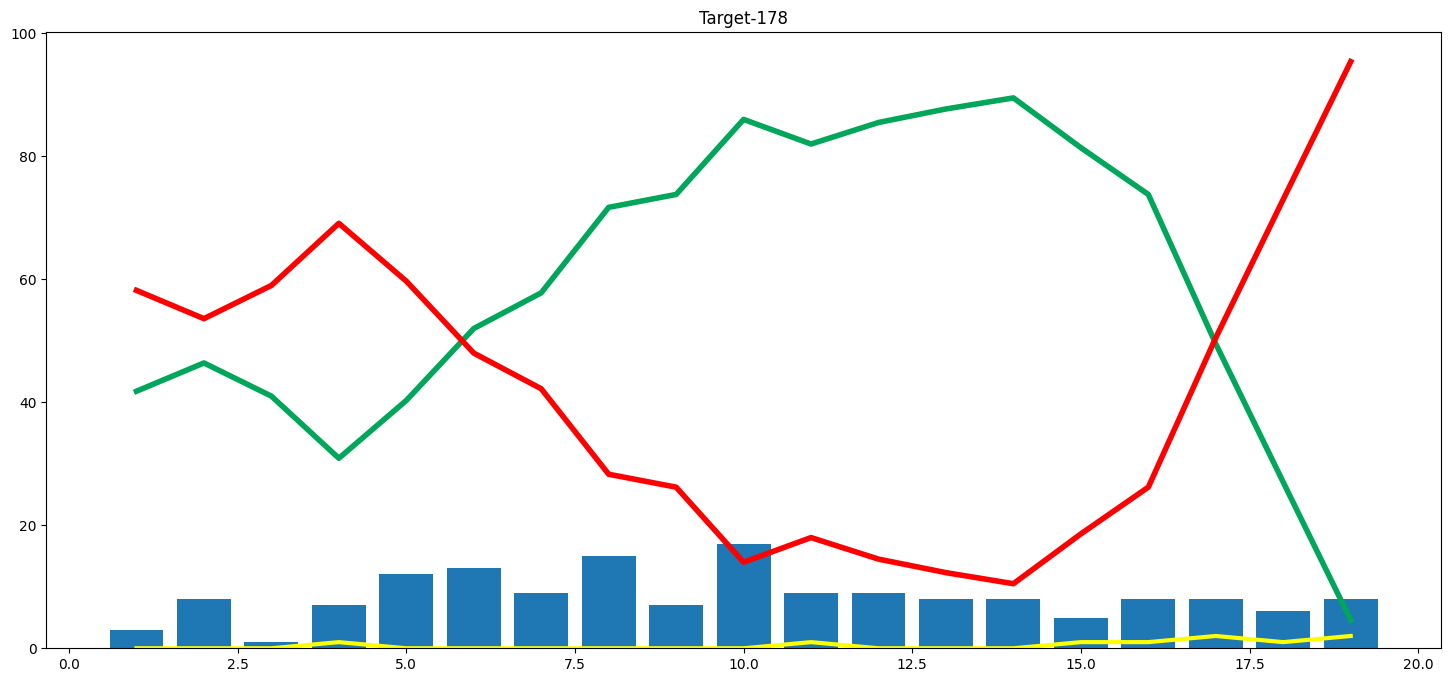

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,8))
plt.plot(temp_df['end_of_over'],temp_df['wickets_in_over'],color='yellow',linewidth=3)
plt.plot(temp_df['end_of_over'],temp_df['win'],color='#00a65a',linewidth=4)
plt.plot(temp_df['end_of_over'],temp_df['lose'],color='red',linewidth=4)
plt.bar(temp_df['end_of_over'],temp_df['runs_after_over'])
plt.title('Target-' + str(target))

In [53]:
teams

['Sunrises Hyderabad',
 'Mumbai Indians',
 'Royal Challengers Bangalore',
 'Kolkata Knight Riders',
 'Kings XI Punjab',
 'Chennai Super Kings',
 'Rajasthan Royals',
 'Delhi Capitals']

In [54]:
delivery_df['city'].unique()

<ArrowStringArray>
[     'Bangalore',         'Mumbai',         'Indore',        'Kolkata',
          'Delhi',     'Chandigarh',         'Jaipur',      'Hyderabad',
        'Chennai',      'Cape Town', 'Port Elizabeth',         'Durban',
      'Centurion',    'East London',   'Johannesburg',      'Kimberley',
   'Bloemfontein',      'Ahmedabad',        'Cuttack',         'Nagpur',
     'Dharamsala',  'Visakhapatnam',           'Pune',         'Raipur',
         'Ranchi',      'Abu Dhabi',        'Sharjah',              nan,
         'Mohali',      'Bengaluru']
Length: 30, dtype: str

In [ ]:
import pickle
pickle.dump(pipe, open('pipe.pkl', 'wb'))

In [ ]:
import os
print(os.getcwd())